## Predicción de Rating Promedio 

Desarrollar un modelo de regresión utilizando Keras para predecir el rating que un usuario le dará a una pelicula, a partir de variables categoricas y numericas como edad. género, dispositivo, idioma género de la pelicula y comportamiento de la visualizacion.

In [3]:
#!pip install tensorflow

In [4]:
import pandas as pd
df = pd.read_csv("recomendaciones_rating.csv")
df.head()

,usuario_edad,usuario_genero,pelicula_duracion,pelicula_genero,temporada_visita,años_desde_estreno,veces_vista_pelicula,dispositivo_usuario,idioma_preferido,duracion_vista_real,popularidad_streaming,rating_promedio_usuario
0,56,Femenino,71,Acción,Primavera,1,3454,Móvil,Inglés,51,8270,2.50
1,46,Masculino,98,Comedia,Verano,5,9820,Móvil,Español,77,1860,4.80
2,32,Masculino,137,Acción,Primavera,4,7201,Computadora,Inglés,150,6390,3.93
3,60,Masculino,134,Comedia,Verano,10,4843,Móvil,Español,144,6191,3.39
4,25,Femenino,152,Comedia,Primavera,6,9051,Smart TV,Español,163,6734,1.62


## Explorar el Data Set

In [6]:
df.describe()

,usuario_edad,pelicula_duracion,años_desde_estreno,veces_vista_pelicula,duracion_vista_real,popularidad_streaming,rating_promedio_usuario
count,2600.000000,2600.000000,2600.000000,2600.000000,2600.000000,2600.000000,2600.000000
mean,41.114615,124.454615,6.215769,5025.140385,87.652308,5516.161538,2.997596
std,13.514614,31.471642,3.728160,2903.024862,37.617522,2590.370780,1.163981
min,18.000000,70.000000,0.000000,101.000000,22.000000,1001.000000,1.010000
25%,29.000000,97.000000,3.000000,2448.750000,58.000000,3203.750000,1.970000
50%,42.000000,125.000000,6.000000,5035.000000,82.000000,5618.500000,3.020000
75%,53.000000,152.000000,10.000000,7582.250000,113.000000,7777.750000,4.002500
max,64.000000,179.000000,12.000000,9995.000000,196.000000,9996.000000,5.000000


## Preprocesamiento, Separar variables predictoras y Objetivo

In [8]:
# Variable Objetivo
y = df["rating_promedio_usuario"]

In [9]:
# Variable predictoras 
X = pd.get_dummies(df.drop("rating_promedio_usuario", axis=1), drop_first=True)

## Visualizar la distribucion del rating promedio

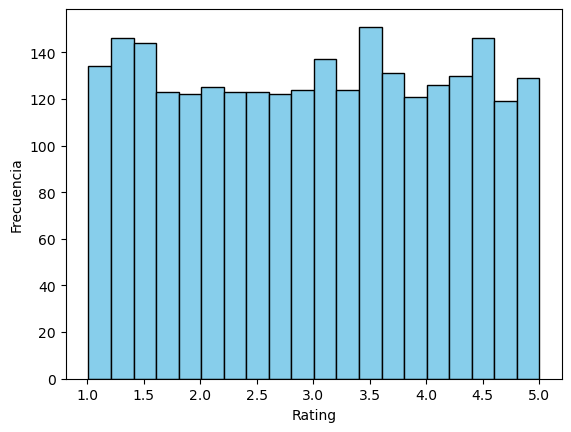

In [11]:
import matplotlib.pyplot as plt
plt.hist(y, bins=20, color="skyblue", edgecolor="black")
plt.xlabel("Distribución de rating promedio")
plt.xlabel("Rating")
plt.ylabel("Frecuencia")
plt.show()

## Normalizar las variables predictoras

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [14]:
# Detectar colummas categoricas de tipo texto
columnas_categoricas = X.select_dtypes(include="object").columns

# Aplicar codificación One-Hot Encoding a columnas categoricas
X_encoded = pd.get_dummies(X, columns=columnas_categoricas, drop_first=True)


In [15]:
# Escalar las variables númericas ya convertidas
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

## Dividir los datos en entrenamiento y prueba

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled,y, test_size=0.2, random_state=42)

## Creación del modelo con una red secuencial usando keras

In [19]:
from tensorflow.keras.models import Sequential # Para crear un modelo secuencial (Una tras otra)
from tensorflow.keras.layers import Dense # Para agregar capas densas(totalmente conectadas)


# Iniciar el modelo secuencial

modelo = Sequential()


#Agregar la primera capa con 128 neuronas y activación ReLu
modelo.add(Dense(128, input_dim= X_train.shape[1], activation="relu"))

#Segunda capa oculta con 64 neuronas y activación ReLu
modelo.add(Dense(64, activation="relu"))


#Tercera capa oculta con 32 neuronas y activación ReLu
#Reducimos la dimención y sigue aprendiendo patrones
modelo.add(Dense(32, activation="relu"))

# Capa de salida con una sola neurona( Ya que es un problema de regresion)

modelo.add(Dense(1))

#Compilamos el modelo
# el optimizador adam es algoritmo que ajusta los pesos de la red para que aprenda
# loss="mean_squared_error" es la función que mide que tan mal o bien esta prediciendo el modelo(error cuadratico medio)
modelo.compile(optimizer="adam", loss="mean_squared_error")


#Entrenar el modelo durante 30 epocas con validación del 20 % de los datos
historial = modelo.fit(X_train,y_train, epochs=200, validation_split=0.2)


C:\ProgramData\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/200
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 6.8919 - val_loss: 1.4449
Epoch 2/200
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.4529 - val_loss: 1.3808
Epoch 3/200
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.3328 - val_loss: 1.3841
Epoch 4/200
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.3365 - val_loss: 1.4220
Epoch 5/200
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.3312 - val_loss: 1.3932
Epoch 6/200
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.2692 - val_loss: 1.3805
Epoch 7/200
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.2798 - val_loss: 1.3862
Epoch 8/200
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.2305 - val_loss: 1.3796
Epoch 9/200
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.2161 - val_loss: 1.3924
Epoch 10/200
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.2860 - val_loss: 1.4055
Epoch 11/200
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.1861 - val_loss: 1.4371
Epoch 12/200
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.

## Evaluación del modelo

In [21]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

#.flatten()  Convierte un arreglo multidimensional a un vector unidimensional
y_pred = modelo.predict(X_test).flatten()

mse = mean_squared_error(y_test, y_pred)

mae = mean_absolute_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"r2:: {r2:.2f}")


17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
MSE: 2.62
MAE: 1.31
r2:: -0.78


## Prediccion con nuevos registros 

In [36]:
nuevos = pd.DataFrame({
        "usuario_edad": [28,45],
        "usuario_genero": ["Femenino", "Masculino"],
        "pelicula_duracion": [120,95],
        "pelicula_genero": ["Acción","Comedia"],
        "temporada_visita":["Primavera","Invierno"],
        "años_desde_estreno":[2,10],
        "popularidad_streaming":[5000,1300],
        "dispositivo_usuario":["Smartphone","TV"],
        "idioma_preferido": ["Español","Inglés"],
        "duracion_vista_real": [110,80],
      "veces_vista_pelicula":[1,2]
})

In [38]:
nuevos_dummies = pd.get_dummies(nuevos, drop_first=True)

#Rellenando valores faltantes
nuevos_dummies = nuevos_dummies.reindex(columns=X.columns, fill_value=0)

#Escalar y predecir
nuevos_scaled = scaler.transform(nuevos_dummies)

#Generar las prediciones 
prediciones = modelo.predict(nuevos_scaled).round(2)

#Mostrar los resultados
resultado =  pd.concat([nuevos, pd.DataFrame(prediciones, columns =["rating_promedio_predicho"])], axis=1)

print(resultado)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
   usuario_edad usuario_genero  pelicula_duracion pelicula_genero  \
0            28       Femenino                120          Acción   
1            45      Masculino                 95         Comedia   

  temporada_visita  años_desde_estreno  popularidad_streaming  \
0        Primavera                   2                   5000   
1         Invierno                  10                   1300   

  dispositivo_usuario idioma_preferido  duracion_vista_real  \
0          Smartphone          Español                  110   
1                  TV           Inglés                   80   

   veces_vista_pelicula  rating_promedio_predicho  
0                     1                      1.72  
1                     2                      2.25  
